# EDA: Missing Value Patterns, V-Feature Reduction, Baseline Loss

This notebook covers three things before any modelling: whether missingness
carries a fraud signal, how to handle the 339 anonymized V-features, and what
the dataset costs under a no-model baseline.

In [21]:
import pandas as pd
import numpy as np
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# Consistent visual style across all plots
sns.set_style('darkgrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Load the merged & memory-optimized dataset from the previous notebook
print('Loading dataset...')
split_train = pd.read_parquet('../data/split_train_raw.parquet')
split_test  = pd.read_parquet('../data/split_test_raw.parquet')
print(f'Loaded split_train: {split_train.shape}')
print(f'Loaded split_test:  {split_test.shape}')

Loading dataset...
Loaded split_train: (472432, 434)
Loaded split_test:  (118108, 434)


## Missing Value Patterns

Rather than dropping columns with too many NaNs, we check whether the
missingness rate itself differs between fraud and non-fraud transactions
(MNAR). If it does, the NaN pattern is informative and should be encoded as
a feature rather than discarded.

In [22]:
# Overall missing rate per column
total_missing    = split_train.isnull().mean().rename('missing_rate_total')

# Missing rate ONLY in fraud transactions
fraud_missing    = split_train[split_train['isFraud'] == 1].isnull().mean().rename('missing_rate_fraud')

# Missing rate ONLY in legitimate transactions
nonfraud_missing = split_train[split_train['isFraud'] == 0].isnull().mean().rename('missing_rate_nonfraud')

# Combine into one DataFrame for easy comparison
missing_df = pd.concat([total_missing, fraud_missing, nonfraud_missing], axis=1)

# Delta: how much does missingness differ between fraud and non-fraud?
# Some columns share an identical missingness pattern (e.g. transaction + identity columns dropped together), which can create duplicate index
# entries after the concat above -- keep the first occurrence only
missing_df['delta'] = missing_df['missing_rate_fraud'] - missing_df['missing_rate_nonfraud']

# Filter: columns with >90% NaN overall
high_missing = missing_df[missing_df['missing_rate_total'] > 0.90].sort_values('delta', ascending=False)
print(f'Columns with >90% NaN: {len(high_missing)}')

# Signal candidates: |delta| > 5 percentage points = statistically meaningful
signal_cols = high_missing[abs(high_missing['delta']) > 0.05]
print(f'Of those, with fraud signal (|delta| > 5pp): {len(signal_cols)}')
print()
print(signal_cols[['missing_rate_total', 'missing_rate_fraud', 'missing_rate_nonfraud', 'delta']]
      .round(3).to_string())

Columns with >90% NaN: 12
Of those, with fraud signal (|delta| > 5pp): 3

       missing_rate_total  missing_rate_fraud  missing_rate_nonfraud  delta
id_18               0.921               0.815                  0.925 -0.109
dist2               0.932               0.817                  0.936 -0.120
D7                  0.937               0.730                  0.944 -0.214


In [23]:
#drop duplicate index entries (keep first occurrence only)
missing_df = missing_df[~missing_df.index.duplicated(keep='first')]

print(f"Duplikate nach Fix: {missing_df.index.duplicated().sum()}")

Duplikate nach Fix: 0


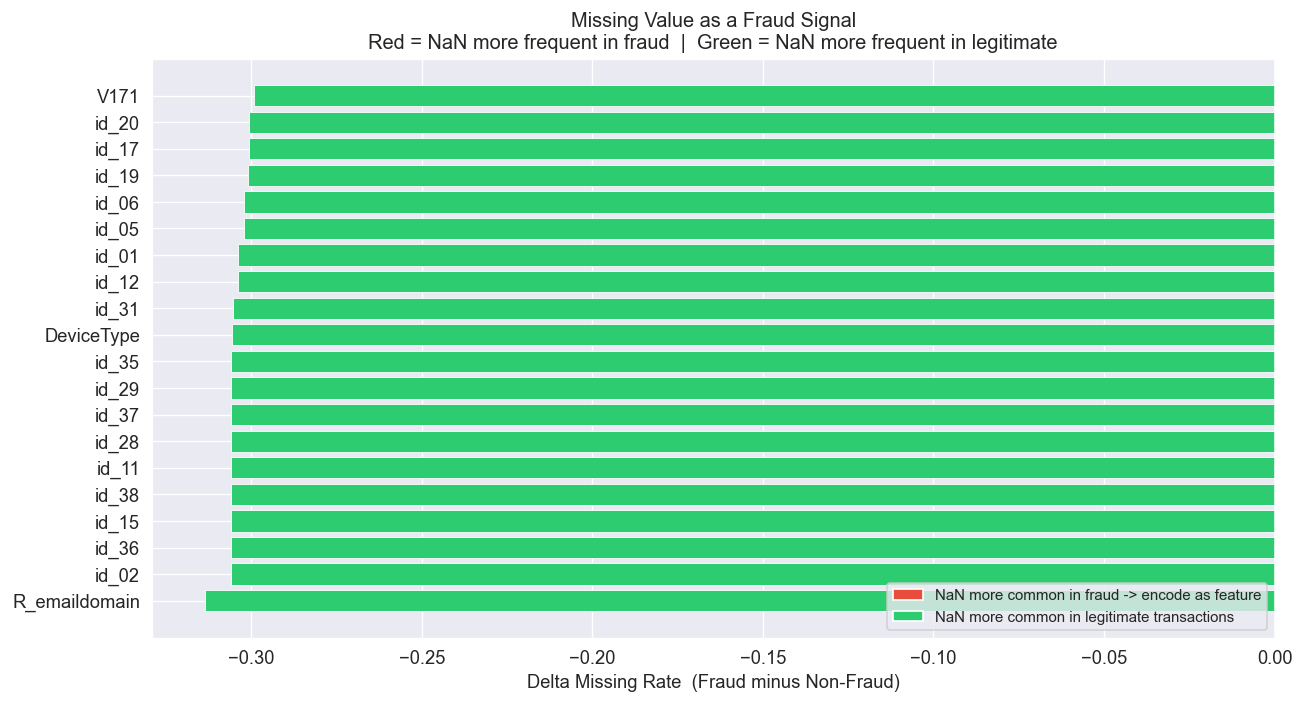

Saved: reports/missing_value_signal.png


In [24]:
# Rank by absolute delta so both directions of the effect can surface

top_signal = missing_df[
    abs(missing_df['delta']) > 0.03
].assign(abs_delta=lambda d: d['delta'].abs()) \
 .sort_values('abs_delta', ascending=False).head(20) \
 .sort_values('delta')

colors = ['#e74c3c' if d > 0 else '#2ecc71' for d in top_signal['delta']]

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(top_signal.index, top_signal['delta'], color=colors, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='white', linewidth=1.5)
ax.set_xlabel('Delta Missing Rate  (Fraud minus Non-Fraud)', fontsize=11)
ax.set_title(
    'Missing Value as a Fraud Signal\n'
    'Red = NaN more frequent in fraud  |  Green = NaN more frequent in legitimate',
    fontsize=12
)
legend_elements = [
    Patch(facecolor='#e74c3c', label='NaN more common in fraud -> encode as feature'),
    Patch(facecolor='#2ecc71', label='NaN more common in legitimate transactions')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('../reports/missing_value_signal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: reports/missing_value_signal.png')

In [25]:
# All 20 strongest signals point one direction (NaN more common in legit transactions) -- verified this isn't a sorting artifact by checking how many
# columns have a positive delta at all
print(missing_df.index.duplicated().sum())
print(missing_df.shape)
print(missing_df[abs(missing_df['delta']) > 0.03].shape)
print(missing_df[abs(missing_df['delta']) > 0.03]['delta'].abs().nlargest(20))

0
(434, 4)
(293, 4)
R_emaildomain    0.313499
id_02            0.306022
id_11            0.305774
id_15            0.305774
id_28            0.305774
id_29            0.305774
id_35            0.305774
id_36            0.305774
id_37            0.305774
id_38            0.305774
DeviceType       0.305746
id_31            0.305256
id_01            0.303855
id_12            0.303855
id_05            0.302231
id_06            0.302231
id_19            0.300806
id_17            0.300719
id_20            0.300601
V169             0.299202
Name: delta, dtype: float64


In [26]:
signal_feature_cols = missing_df[
    (missing_df['missing_rate_total'] > 0.50) &
    (abs(missing_df['delta']) > 0.03)
].index.tolist()

for col in signal_feature_cols:
    split_train[f'{col}_isnan'] = split_train[col].isnull().astype(np.int8)
    split_test[f'{col}_isnan']  = split_test[col].isnull().astype(np.int8)

print(f'Created {len(signal_feature_cols)} NaN-indicator features (columns chosen from split_train)')
print(f'Examples: {[c + "_isnan" for c in signal_feature_cols[:4]]}...')

# Email domain match: pure row-wise comparison, no statistic learned --
# safe to compute independently on both partitions
for df_name, df in [('split_train', split_train), ('split_test', split_test)]:
    if 'P_emaildomain' in df.columns and 'R_emaildomain' in df.columns:
        df['email_match'] = (df['P_emaildomain'] == df['R_emaildomain']).astype(np.int8)

match_fraud_rate    = split_train[split_train['email_match'] == 1]['isFraud'].mean()
mismatch_fraud_rate = split_train[split_train['email_match'] == 0]['isFraud'].mean()
overall_fraud_rate  = split_train['isFraud'].mean()

print(f'\nEmail Domain Match Analysis (split_train only, for reporting):')
print(f'  Overall fraud rate:              {overall_fraud_rate:.2%}')
print(f'  Fraud rate when emails MATCH:    {match_fraud_rate:.2%}')
print(f'  Fraud rate when emails MISMATCH: {mismatch_fraud_rate:.2%}')
mult = match_fraud_rate / overall_fraud_rate if overall_fraud_rate > 0 else 0
print(f'  -> Email match is {mult:.1f}x more likely to be fraud than average')

Created 220 NaN-indicator features (columns chosen from split_train)
Examples: ['dist1_isnan', 'dist2_isnan', 'R_emaildomain_isnan', 'D5_isnan']...

Email Domain Match Analysis (split_train only, for reporting):
  Overall fraud rate:              3.51%
  Fraud rate when emails MATCH:    9.29%
  Fraud rate when emails MISMATCH: 2.23%
  -> Email match is 2.6x more likely to be fraud than average


## V-Feature Reduction via PCA

339 anonymized, Vesta-engineered columns (V1-V339), highly correlated and
without documented meaning. PCA is applied to this block specifically, not
dataset-wide, to preserve the interpretability of named features.

In [27]:
v_cols = [c for c in split_train.columns if c.startswith('V') and c[1:].isdigit()]
print(f'Pure V-feature columns matched: {len(v_cols)}')
assert len(v_cols) == 339, f'Expected 339 V-features, got {len(v_cols)} -- check filter logic'

print(f'V-columns found: {len(v_cols)}')
print(f'Memory used by V-columns alone: {split_train[v_cols].memory_usage().sum() / 1024**2:.1f} MB')

V_train = split_train[v_cols].copy()
V_test  = split_test[v_cols].copy()

v_median = V_train.median()
V_train = V_train.fillna(v_median)
V_test  = V_test.fillna(v_median)

scaler = StandardScaler()
V_train_scaled = scaler.fit_transform(V_train)
V_test_scaled  = scaler.transform(V_test)

print(f'Scaled shape (train): {V_train_scaled.shape}')
print(f'Scaled shape (test):  {V_test_scaled.shape}')

Pure V-feature columns matched: 339
V-columns found: 339
Memory used by V-columns alone: 610.9 MB
Scaled shape (train): (472432, 339)
Scaled shape (test):  (118108, 339)


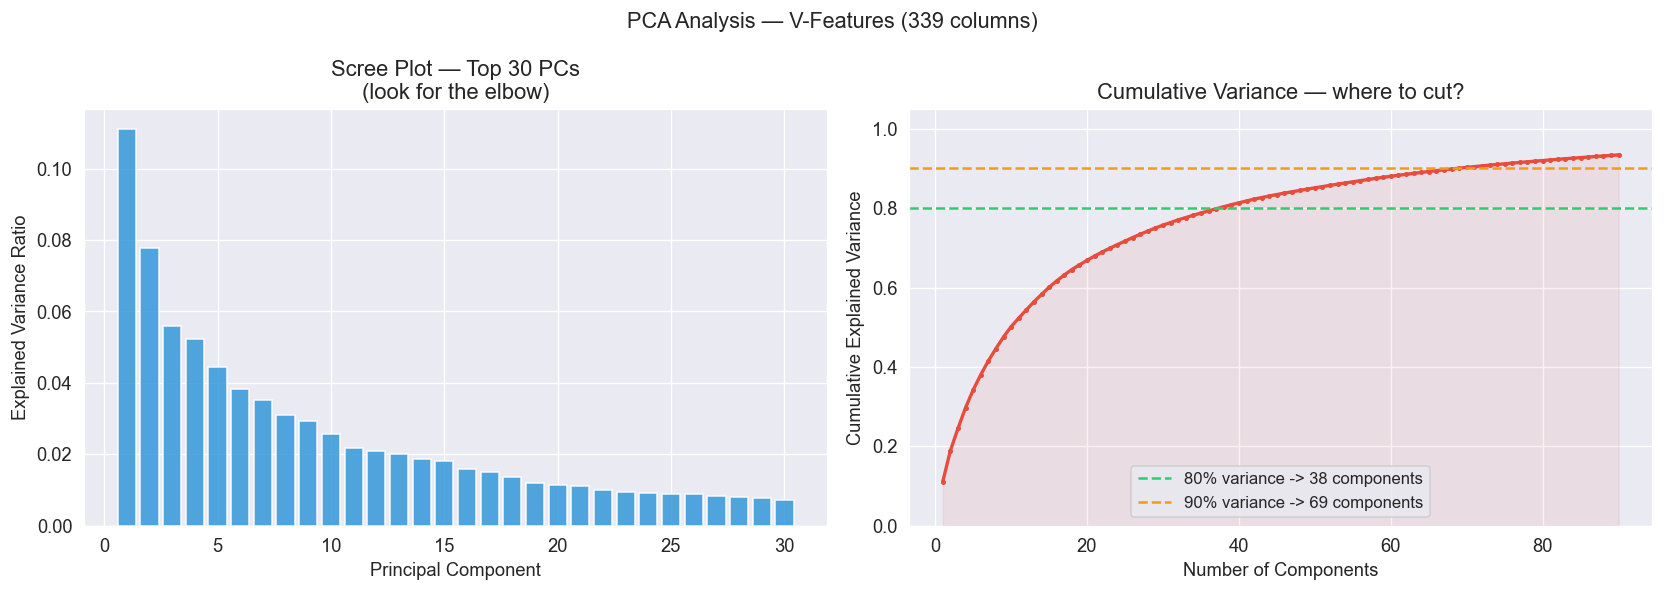

Recommendation: 38 components for 80% variance | 69 for 90%


In [32]:
# Explore: how many components are needed to retain 80% / 90% of variance?
pca_full = PCA(n_components=90, random_state=42)
pca_full.fit(V_train_scaled)

explained  = pca_full.explained_variance_ratio_   # % variance per component
cumulative = np.cumsum(explained)                  # running total

# How many components do we need to explain 80% and 90% of total variance?
n_80 = np.argmax(cumulative >= 0.80) + 1   # +1 because argmax is 0-indexed
n_90 = np.argmax(cumulative >= 0.90) + 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PCA Analysis — V-Features (339 columns)', fontsize=13)

ax1.bar(range(1, 31), explained[:30], color='#3498db', alpha=0.85, edgecolor='white')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('Scree Plot — Top 30 PCs\n(look for the elbow)')

ax2.plot(range(1, 91), cumulative, marker='.', color='#e74c3c', linewidth=2, markersize=4)
ax2.axhline(0.80, color='#2ecc71', linestyle='--', linewidth=1.5,
            label=f'80% variance -> {n_80} components')
ax2.axhline(0.90, color='#f39c12', linestyle='--', linewidth=1.5,
            label=f'90% variance -> {n_90} components')
ax2.fill_between(range(1, 91), cumulative, alpha=0.08, color='#e74c3c')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_title('Cumulative Variance — where to cut?')
ax2.legend(fontsize=10)
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('../reports/pca_scree_v_features.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Recommendation: {n_80} components for 80% variance | {n_90} for 90%')

In [29]:
N_COMPONENTS = max(n_80, 15)
print(f'Applying PCA with {N_COMPONENTS} components...')

# fit ONLY on split_train -- the PCA components themselves are a learned
# transformation and must not be influenced by test-period data
pca = PCA(n_components=N_COMPONENTS, random_state=42)
V_train_pca = pca.fit_transform(V_train_scaled)
V_test_pca  = pca.transform(V_test_scaled)

pca_cols = [f'V_PC{i+1}' for i in range(N_COMPONENTS)]
pca_train_df = pd.DataFrame(V_train_pca, columns=pca_cols, index=split_train.index)
pca_test_df  = pd.DataFrame(V_test_pca, columns=pca_cols, index=split_test.index)

mem_before = split_train[v_cols].memory_usage().sum() / 1024**2

split_train = split_train.drop(columns=v_cols)
split_train = pd.concat([split_train, pca_train_df], axis=1)

split_test = split_test.drop(columns=v_cols)
split_test = pd.concat([split_test, pca_test_df], axis=1)

mem_after = split_train[pca_cols].memory_usage().sum() / 1024**2

print(f'Compression complete:')
print(f'  {len(v_cols)} V-columns -> {N_COMPONENTS} principal components')
print(f'  Variance retained (split_train): {pca.explained_variance_ratio_.sum():.1%}')
print(f'  Memory: {mem_before:.1f} MB -> {mem_after:.1f} MB  (saved {mem_before-mem_after:.1f} MB)')
print(f'  split_train shape: {split_train.shape}')
print(f'  split_test shape:  {split_test.shape}')

Applying PCA with 38 components...
Compression complete:
  339 V-columns -> 38 principal components
  Variance retained (split_train): 80.4%
  Memory: 610.9 MB -> 68.5 MB  (saved 542.5 MB)
  split_train shape: (472432, 354)
  split_test shape:  (118108, 354)


## UMAP Visualization

Projects the high-dimensional feature space to 2D to check whether fraud
and legitimate transactions separate into distinct clusters.

In [ ]:
N_FRAUD_SAMPLE = min(3000, int(split_train['isFraud'].sum()))
N_TOTAL_SAMPLE = 50_000
N_LEGIT_SAMPLE = N_TOTAL_SAMPLE - N_FRAUD_SAMPLE

sample_fraud    = split_train[split_train['isFraud'] == 1].sample(N_FRAUD_SAMPLE, random_state=42)
sample_nonfraud = split_train[split_train['isFraud'] == 0].sample(N_LEGIT_SAMPLE, random_state=42)

sample = pd.concat([sample_fraud, sample_nonfraud]).sample(frac=1, random_state=42)
print(f'UMAP sample: {len(sample):,} rows')
print(f'  Fraud: {(sample["isFraud"]==1).sum():,}  ({(sample["isFraud"]==1).mean():.1%} of sample)')
print(f'  Legit: {(sample["isFraud"]==0).sum():,}')

umap_features = pca_cols + ['TransactionAmt', 'TransactionDT']
umap_features = [f for f in umap_features if f in sample.columns]

X_umap = sample[umap_features].fillna(0).values
X_umap = StandardScaler().fit_transform(X_umap)
y_umap = sample['isFraud'].values

print(f'UMAP input shape: {X_umap.shape}')

UMAP sample: 50,000 rows
  Fraud: 3,000  (6.0% of sample)
  Legit: 47,000
UMAP input shape: (50000, 40)
Running UMAP... (takes roughly 2-3 minutes)


In [34]:
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    metric='euclidean',
    random_state=42,
    verbose=True
)

embedding = reducer.fit_transform(X_umap)
print('UMAP complete')
print(f'Embedding shape: {embedding.shape}  (each of the {len(embedding):,} rows is now a 2D point)')

UMAP(n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Mon Jun 29 19:23:16 2026 Construct fuzzy simplicial set
Mon Jun 29 19:23:16 2026 Finding Nearest Neighbors
Mon Jun 29 19:23:16 2026 Building RP forest with 16 trees
Mon Jun 29 19:23:23 2026 NN descent for 16 iterations
	 1  /  16
	 2  /  16
	 3  /  16
	Stopping threshold met -- exiting after 3 iterations
Mon Jun 29 19:23:43 2026 Finished Nearest Neighbor Search
Mon Jun 29 19:23:48 2026 Construct embedding


Epochs completed:   0%|            1/200 [00:01]

	completed  0  /  200 epochs


Epochs completed:  11%| █          22/200 [00:04]

	completed  20  /  200 epochs


...

	completed  160  /  200 epochs


Epochs completed:  91%| █████████  182/200 [00:42]

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [00:45]

Mon Jun 29 19:24:40 2026 Finished embedding
UMAP complete
Embedding shape: (50000, 2)  (each of the 50,000 rows is now a 2D point)


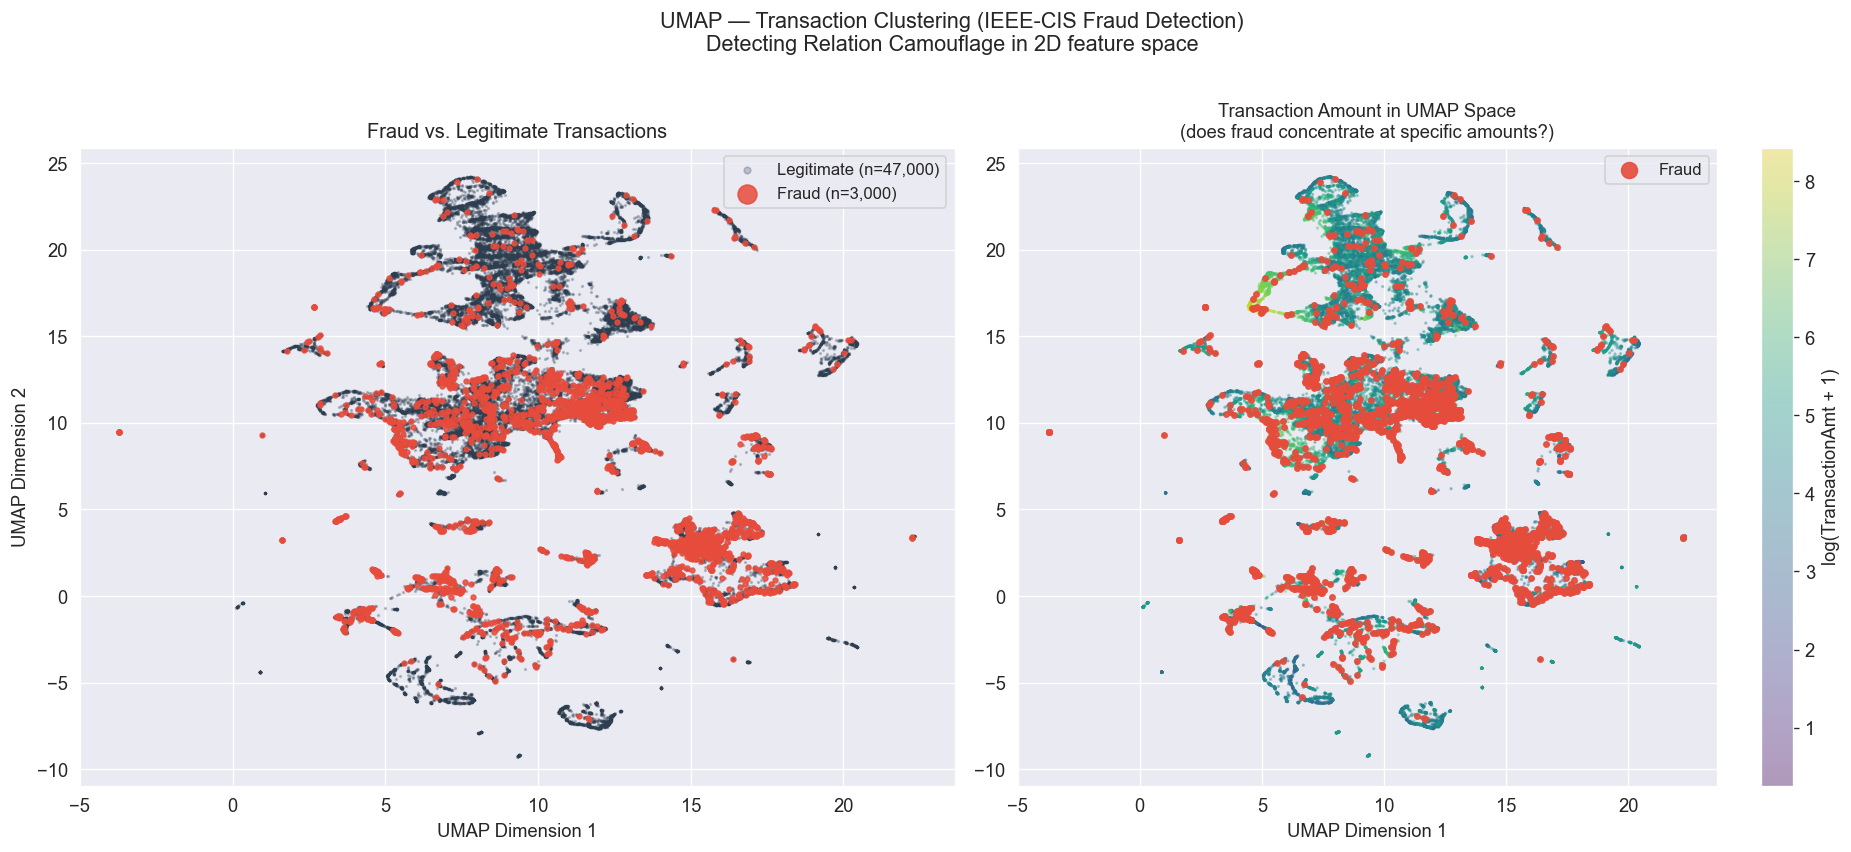

Saved: reports/umap_fraud_clusters.png

INTERPRETATION GUIDE (based on Dual-Path Graph Filtering paper, 2026):
  Clear fraud clusters  -> Structural patterns exist -> XGBoost will be very strong
  Partially clustered   -> Some camouflage -> SHAP values explain the hidden signals
  Fraud spread evenly   -> Relation Camouflage working -> GNN is the logical next step


In [35]:
mask_legit = y_umap == 0
mask_fraud = y_umap == 1

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    'UMAP — Transaction Clustering (IEEE-CIS Fraud Detection)\n'
    'Detecting Relation Camouflage in 2D feature space',
    fontsize=13, y=1.01
)

axes[0].scatter(embedding[mask_legit, 0], embedding[mask_legit, 1],
                c='#2c3e50', s=1, alpha=0.25, label=f'Legitimate (n={mask_legit.sum():,})')
axes[0].scatter(embedding[mask_fraud, 0], embedding[mask_fraud, 1],
                c='#e74c3c', s=8, alpha=0.85, label=f'Fraud (n={mask_fraud.sum():,})')
axes[0].set_title('Fraud vs. Legitimate Transactions', fontsize=12)
axes[0].legend(markerscale=4, fontsize=10, loc='upper right')
axes[0].set_xlabel('UMAP Dimension 1')
axes[0].set_ylabel('UMAP Dimension 2')

amt_log = np.log1p(sample['TransactionAmt'].values)
sc = axes[1].scatter(embedding[:, 0], embedding[:, 1],
                     c=amt_log, cmap='viridis', s=1, alpha=0.35)
plt.colorbar(sc, ax=axes[1], label='log(TransactionAmt + 1)')
axes[1].scatter(embedding[mask_fraud, 0], embedding[mask_fraud, 1],
                c='#e74c3c', s=10, alpha=0.9, label='Fraud', zorder=5)
axes[1].set_title('Transaction Amount in UMAP Space\n(does fraud concentrate at specific amounts?)', fontsize=11)
axes[1].legend(markerscale=3, fontsize=10)
axes[1].set_xlabel('UMAP Dimension 1')

plt.tight_layout()
plt.savefig('../reports/umap_fraud_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: reports/umap_fraud_clusters.png')
print()
print('INTERPRETATION GUIDE (based on Dual-Path Graph Filtering paper, 2026):')
print('  Clear fraud clusters  -> Structural patterns exist -> XGBoost will be very strong')
print('  Partially clustered   -> Some camouflage -> SHAP values explain the hidden signals')
print('  Fraud spread evenly   -> Relation Camouflage working -> GNN is the logical next step')

## Baseline Loss Analysis

Cost exposure under a no-model baseline (every fraud transaction is a missed
false negative), used later to motivate cost-sensitive threshold
optimization rather than accuracy-based evaluation.

In [36]:
COST_FN = 150  # average fraud transaction amount, USD
COST_FP = 10   # customer friction / support cost, USD

fraud_transactions = split_train[split_train['isFraud'] == 1]['TransactionAmt']
total_fraud_loss = fraud_transactions.sum()
avg_fraud_amt    = fraud_transactions.mean()
median_fraud_amt = fraud_transactions.median()
n_fraud          = len(fraud_transactions)
n_total          = len(split_train)

baseline_cost = n_fraud * COST_FN

print(f'Total transactions:        {n_total:,}')
print(f'Fraud transactions:        {n_fraud:,} ({n_fraud/n_total:.2%})')
print(f'Total fraud losses:        ${total_fraud_loss:,.0f}')
print(f'Average fraud amount:      ${avg_fraud_amt:.2f}')
print(f'Median fraud amount:       ${median_fraud_amt:.2f}')
print(f'Baseline cost (no model):  ${baseline_cost:,.0f}')

Total transactions:        472,432
Fraud transactions:        16,599 (3.51%)
Total fraud losses:        $2,473,910
Average fraud amount:      $149.04
Median fraud amount:       $76.13
Baseline cost (no model):  $2,489,850


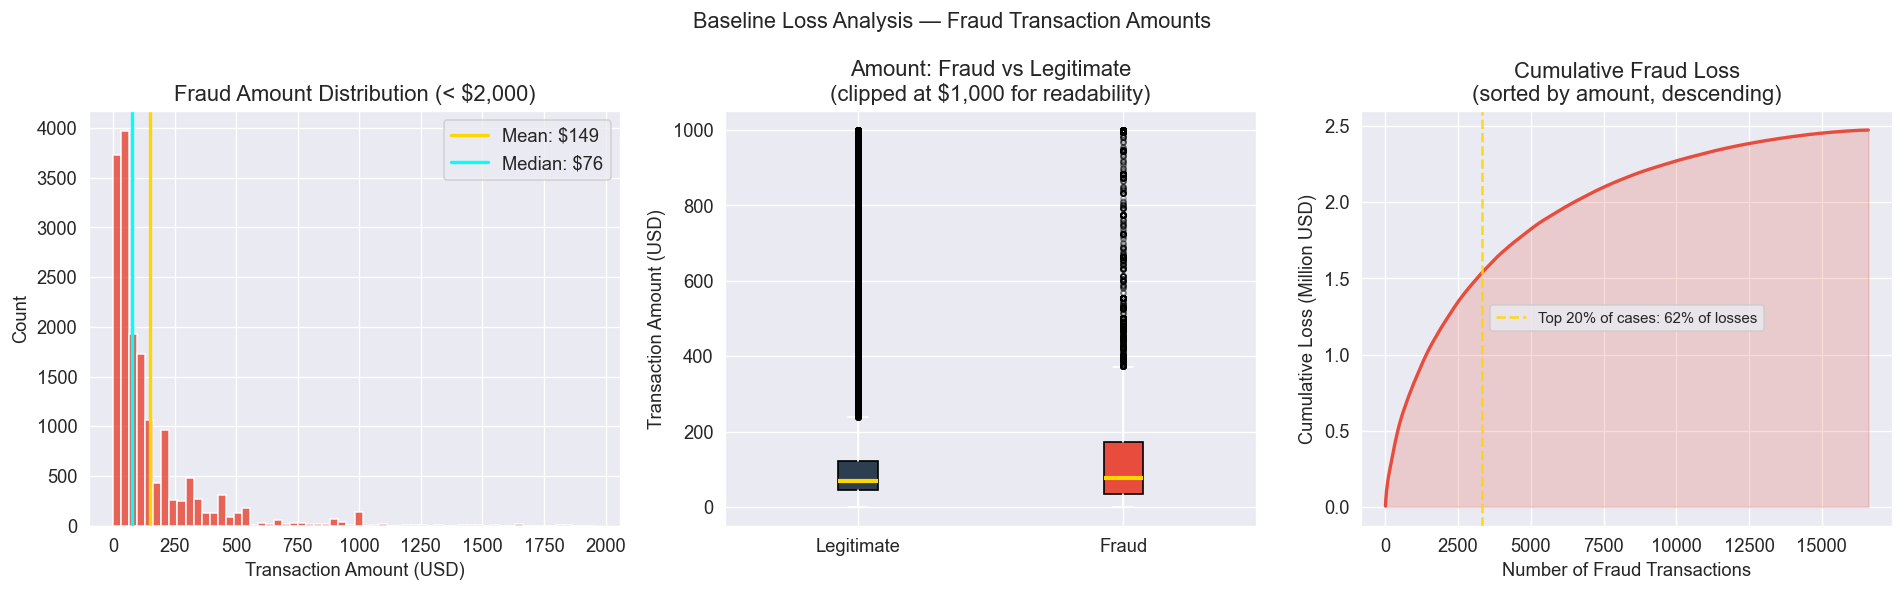

Saved: reports/baseline_loss_analysis.png
Pareto insight: Top 20% of fraud cases cause 62% of total losses.
-> Catching high-value fraud first pays off disproportionately.


In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Baseline Loss Analysis — Fraud Transaction Amounts', fontsize=13)

axes[0].hist(fraud_transactions[fraud_transactions < 2_000], bins=60,
             color='#e74c3c', edgecolor='white', alpha=0.85)
axes[0].axvline(avg_fraud_amt, color='gold', linewidth=2, label=f'Mean: ${avg_fraud_amt:.0f}')
axes[0].axvline(median_fraud_amt, color='cyan', linewidth=2, label=f'Median: ${median_fraud_amt:.0f}')
axes[0].set_title('Fraud Amount Distribution (< $2,000)')
axes[0].set_xlabel('Transaction Amount (USD)')
axes[0].set_ylabel('Count')
axes[0].legend()

box_data = [
    split_train[split_train['isFraud'] == 0]['TransactionAmt'].clip(0, 1_000),
    split_train[split_train['isFraud'] == 1]['TransactionAmt'].clip(0, 1_000)
]
bp = axes[1].boxplot(box_data, labels=['Legitimate', 'Fraud'],
                     patch_artist=True,
                     boxprops=dict(facecolor='#2c3e50'),
                     medianprops=dict(color='gold', linewidth=2.5),
                     whiskerprops=dict(color='white'),
                     capprops=dict(color='white'),
                     flierprops=dict(marker='.', color='gray', alpha=0.3))
bp['boxes'][1].set_facecolor('#e74c3c')
axes[1].set_title('Amount: Fraud vs Legitimate\n(clipped at $1,000 for readability)')
axes[1].set_ylabel('Transaction Amount (USD)')

fraud_sorted = fraud_transactions.sort_values(ascending=False)
cum_loss = np.cumsum(fraud_sorted.values)

axes[2].plot(range(len(cum_loss)), cum_loss / 1e6, color='#e74c3c', linewidth=2)
axes[2].fill_between(range(len(cum_loss)), cum_loss / 1e6, alpha=0.2, color='#e74c3c')

idx_20 = int(len(cum_loss) * 0.20)
pct_from_top20 = cum_loss[idx_20] / cum_loss[-1]
axes[2].axvline(idx_20, color='gold', linestyle='--', alpha=0.9,
                label=f'Top 20% of cases: {pct_from_top20:.0%} of losses')
axes[2].set_title('Cumulative Fraud Loss\n(sorted by amount, descending)')
axes[2].set_xlabel('Number of Fraud Transactions')
axes[2].set_ylabel('Cumulative Loss (Million USD)')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../reports/baseline_loss_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: reports/baseline_loss_analysis.png')
print(f'Pareto insight: Top 20% of fraud cases cause {pct_from_top20:.0%} of total losses.')
print('-> Catching high-value fraud first pays off disproportionately.')

In [38]:
print('Saving enriched datasets...')
split_train.to_parquet('../data/split_train_eda.parquet', index=False)
split_test.to_parquet('../data/split_test_eda.parquet', index=False)

new_isnan = [c for c in split_train.columns if '_isnan' in c]
new_pca   = [c for c in split_train.columns if c.startswith('V_PC')]
new_other = ['email_match'] if 'email_match' in split_train.columns else []

print(f'Saved: data/split_train_eda.parquet  {split_train.shape}')
print(f'Saved: data/split_test_eda.parquet   {split_test.shape}')
print(f'New features added this notebook:')
print(f'  {len(new_isnan)} NaN indicator features  (e.g. {new_isnan[:3]})')
print(f'  {len(new_pca)} PCA components           (V_PC1 through V_PC{len(new_pca)})')
print(f'  {len(new_other)} domain feature(s)        {new_other}')

Saving enriched datasets...
Saved: data/split_train_eda.parquet  (472432, 354)
Saved: data/split_test_eda.parquet   (118108, 354)
New features added this notebook:
  220 NaN indicator features  (e.g. ['dist1_isnan', 'dist2_isnan', 'R_emaildomain_isnan'])
  38 PCA components           (V_PC1 through V_PC38)
  1 domain feature(s)        ['email_match']
